In [1]:
import sys
print(sys.executable)

/home/aviraljoshi/projects/nn-from-scratch-credit-default/.venv/bin/python3


In [8]:
from pathlib import Path
import pandas as pd
pd.set_option("display.max_columns",None)
DATA_PATH = Path("../data/raw/default of credit card clients.xls")
raw = pd.read_excel(DATA_PATH, header=1) # used header=1 as real column name is in row 1
raw.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [16]:
# check shape of the dataset
print(raw.shape)

(30000, 25)


In [17]:
# check class balance
target = raw["default payment next month"]
print(target.value_counts())
print(target.value_counts(normalize=True))

default payment next month
0    23364
1     6636
Name: count, dtype: int64
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [18]:
# check missing values
print(raw.isna().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [19]:
# total missing values
print(raw.isna().sum().sum())

0


In [20]:
# checking categorical values
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(raw[col].value_counts().sort_index())

SEX
1    11888
2    18112
Name: count, dtype: int64
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


> #### Initial findings from the categorical columns
- SEX only has 1 and 2, so it matches the documentation.
- EDUCATION has 0, 5 and 6, which the documentation never mentions. That’s 345 customers.
- MARRIAGE has 0, which isn’t documented either. That’s 54 customers.

In [22]:
# check distinct code appear on Pay_* columns
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
for col in pay_cols:
    print(col, sorted(raw[col].unique().tolist()))

PAY_0 [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_2 [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_3 [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_4 [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_5 [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
PAY_6 [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


> #### Findigs
- -2 and 0 appear in every column, but the documentation never mentions them.
- 9 never appears.
- PAY_5 and PAY_6 have no 1 at all. ( No 1 in PAY_5 and PAY_6: in April and May, nobody was exactly one month late, yet some people were two or more months late. That’s strange, and it hints that those months may have been recorded a bit differently. We can’t find out why, so we’ll just note it. )

> #### Most likely fixes
- -2	no credit used that month, so there was nothing to pay
- -1	paid the full bill on time
- 0	paid at least the minimum on time, but carried the rest over to next month
- 1–8	that many months late

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

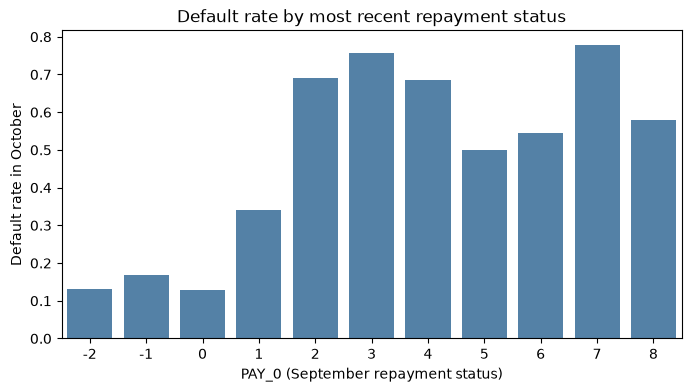

In [26]:
# checking does a customer’s most recent payment status (PAY_0, September) relate to whether they default in October?
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=raw, x="PAY_0", y= "default payment next month", errorbar=None, color="steelblue", ax=ax)
ax.set_xlabel("PAY_0 (September repayment status)")
ax.set_ylabel("Default rate in October")
ax.set_title("Default rate by most recent repayment status")
plt.show()

#### Customers who were late in September default in October far more often than those who weren’t.

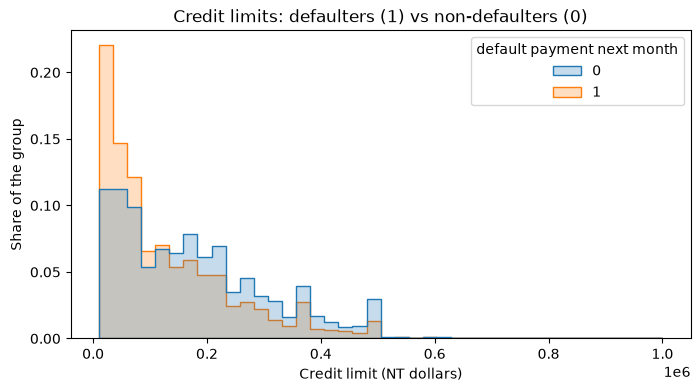

In [29]:
# checking do customers who default tend to have different credit limits (LIMIT_BAL) from those who don’t?
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=raw, x="LIMIT_BAL", hue="default payment next month",
             bins=40, stat="probability", common_norm=False,
             element="step", ax=ax)
ax.set_xlabel("Credit limit (NT dollars)")
ax.set_ylabel("Share of the group")
ax.set_title("Credit limits: defaulters (1) vs non-defaulters (0)")
plt.show()

#### Credit limit is a clue, but a weaker one than payment status.

In [30]:
# checking scale of different number column
raw[["AGE", "LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]].describe()

,AGE,LIMIT_BAL,BILL_AMT1,PAY_AMT1
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,35.485500,167484.322667,51223.330900,5663.580500
std,9.217904,129747.661567,73635.860576,16563.280354
min,21.000000,10000.000000,-165580.000000,0.000000
25%,28.000000,50000.000000,3558.750000,1000.000000
50%,34.000000,140000.000000,22381.500000,2100.000000
75%,41.000000,240000.000000,67091.000000,5006.000000
max,79.000000,1000000.000000,964511.000000,873552.000000


- AGE runs from about 21 to 79.
- LIMIT_BAL runs from 10,000 to 1,000,000.
- BILL_AMT1 goes up to almost a million, and its min is negative.
- PAY_AMT1 runs from 0 to over 800,000.

## What the EDA showed me

1. **Does the most recent payment status (PAY_0) relate to default?**
   Yes, strongly. People who weren't late in September defaulted in October roughly
   13–17% of the time. One month late jumped that to about a third, and two or more
   months late was mostly 50–75%. The jump from 0 to 1 is much bigger than the later
   steps, so the codes aren't evenly spaced. The bars for 4–8 come from very few
   people, so I don't trust them much.

2. **Do defaulters have different credit limits?**
   A bit. Defaulters are bunched more at small limits and non-defaulters spread further
   towards big limits, but the two overlap a lot. So it's a weaker clue than PAY_0.

3. **Are the number columns on very different scales?**
   Yes. AGE goes from 21 to 79 but BILL_AMT1 goes from about -165,000 to about 960,000,
   so I'll need to scale them before training. Negative bills most likely mean the
   customer overpaid, so I'm leaving them as they are.